<a href="https://colab.research.google.com/github/parshanpandey989-lgtm/Project-work-for-web/blob/main/ICT902_Group.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICT902 Assessment 3 – Android Malware Detection

## NATICUSdroid Machine Learning Project

This notebook applies supervised machine learning to classify Android applications as benign or malicious using permission-based features from the NATICUSdroid dataset.

## 1. Import Libraries and Load the Dataset

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [ ]:
# Display scikit-learn version
import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


In [ ]:
# Load the NATICUSdroid dataset
file_path = "/content/data.csv"

df = pd.read_csv(file_path)

# Preview the dataset
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/data.csv'

## 2. Dataset Understanding

In [ ]:
# Check dataset dimensions
print("Number of records:", df.shape[0])
print("Number of variables:", df.shape[1])

NameError: name 'df' is not defined

In [ ]:
# Display column names
print(df.columns.tolist())

['android.permission.GET_ACCOUNTS', 'com.sonyericsson.home.permission.BROADCAST_BADGE', 'android.permission.READ_PROFILE', 'android.permission.MANAGE_ACCOUNTS', 'android.permission.WRITE_SYNC_SETTINGS', 'android.permission.READ_EXTERNAL_STORAGE', 'android.permission.RECEIVE_SMS', 'com.android.launcher.permission.READ_SETTINGS', 'android.permission.WRITE_SETTINGS', 'com.google.android.providers.gsf.permission.READ_GSERVICES', 'android.permission.DOWNLOAD_WITHOUT_NOTIFICATION', 'android.permission.GET_TASKS', 'android.permission.WRITE_EXTERNAL_STORAGE', 'android.permission.RECORD_AUDIO', 'com.huawei.android.launcher.permission.CHANGE_BADGE', 'com.oppo.launcher.permission.READ_SETTINGS', 'android.permission.CHANGE_NETWORK_STATE', 'com.android.launcher.permission.INSTALL_SHORTCUT', 'android.permission.android.permission.READ_PHONE_STATE', 'android.permission.CALL_PHONE', 'android.permission.WRITE_CONTACTS', 'android.permission.READ_PHONE_STATE', 'com.samsung.android.providers.context.permi

In [ ]:
# Check data types
print(df.dtypes.value_counts())

int64    87
Name: count, dtype: int64


In [ ]:
# Display basic dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29332 entries, 0 to 29331
Data columns (total 87 columns):
 #   Column                                                                         Non-Null Count  Dtype
---  ------                                                                         --------------  -----
 0   android.permission.GET_ACCOUNTS                                                29332 non-null  int64
 1   com.sonyericsson.home.permission.BROADCAST_BADGE                               29332 non-null  int64
 2   android.permission.READ_PROFILE                                                29332 non-null  int64
 3   android.permission.MANAGE_ACCOUNTS                                             29332 non-null  int64
 4   android.permission.WRITE_SYNC_SETTINGS                                         29332 non-null  int64
 5   android.permission.READ_EXTERNAL_STORAGE                                       29332 non-null  int64
 6   android.permission.RECEIVE_SMS        

## 3. Data Quality and Pre-processing

In [ ]:
# Check missing values
missing_values = df.isnull().sum().sum()

print("Total missing values:", missing_values)

Total missing values: 0


In [ ]:
# Check repeated rows
duplicate_rows = df.duplicated().sum()

print("Repeated rows:", duplicate_rows)

Repeated rows: 21841


The dataset contains repeated patterns of permissions. We keep these records because different Android apps may request the same combination of permissions, and the dataset does not contain an app identifier that would confirm if repeated rows represent duplicate apps by accident. Removing them without supporting evidence may change the original dataset structure.

In [ ]:
# Check whether all variables contain binary values
binary_check = df.apply(
    lambda column: set(column.dropna().unique()).issubset({0, 1})
)

print("All variables are binary:", binary_check.all())

All variables are binary: True


In [ ]:
# Separate predictors and target variable
X = df.drop(columns=['Result'])
y = df['Result']

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (29332, 86)
Target shape: (29332,)


## 4. Descriptive Analytics

Descriptive analysis is used to examine the class distribution and important permission patterns before predictive modelling.

### 4.1 Target class distribution

In [ ]:
# Calculate target class distribution
target_counts = y.value_counts().sort_index()

target_summary = pd.DataFrame({
    'Class': ['Benign (0)', 'Malware (1)'],
    'Count': [target_counts[0], target_counts[1]]
})

target_summary['Percentage'] = (
    target_summary['Count'] / len(df) * 100
).round(2)

target_summary

,Class,Count,Percentage
0,Benign (0),14632,49.88
1,Malware (1),14700,50.12


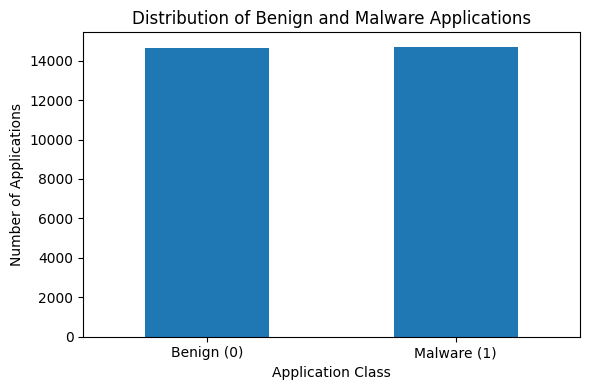

In [ ]:
# Plot target class distribution
target_summary.plot(
    x='Class',
    y='Count',
    kind='bar',
    legend=False,
    figsize=(6, 4)
)

plt.title('Distribution of Benign and Malware Applications')
plt.xlabel('Application Class')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The dataset is almost evenly balanced between benign and malware applications. This reduces the risk that overall accuracy will be dominated by one class and supports fair comparison of the classification models.

### 4.2 Most Frequently Requested Permissions

In [ ]:
# Calculate permission frequencies
permission_frequency = (
    X.mean()
    .sort_values(ascending=False)
    .head(15) * 100
)

permission_frequency.to_frame(
    name='Applications Requesting Permission (%)'
)

,Applications Requesting Permission (%)
android.permission.INTERNET,97.531706
android.permission.ACCESS_NETWORK_STATE,94.903177
android.permission.WRITE_EXTERNAL_STORAGE,66.920087
android.permission.READ_PHONE_STATE,58.737897
android.permission.ACCESS_WIFI_STATE,52.505796
android.permission.WAKE_LOCK,48.087413
android.permission.ACCESS_COARSE_LOCATION,46.389609
android.permission.RECEIVE_BOOT_COMPLETED,45.486158
android.permission.ACCESS_FINE_LOCATION,44.552025
android.permission.VIBRATE,34.903859


Internet and network-related permissions occur frequently across the dataset, indicating that several permissions are common to both application classes. Permission frequency alone therefore does not determine whether an application is malicious.

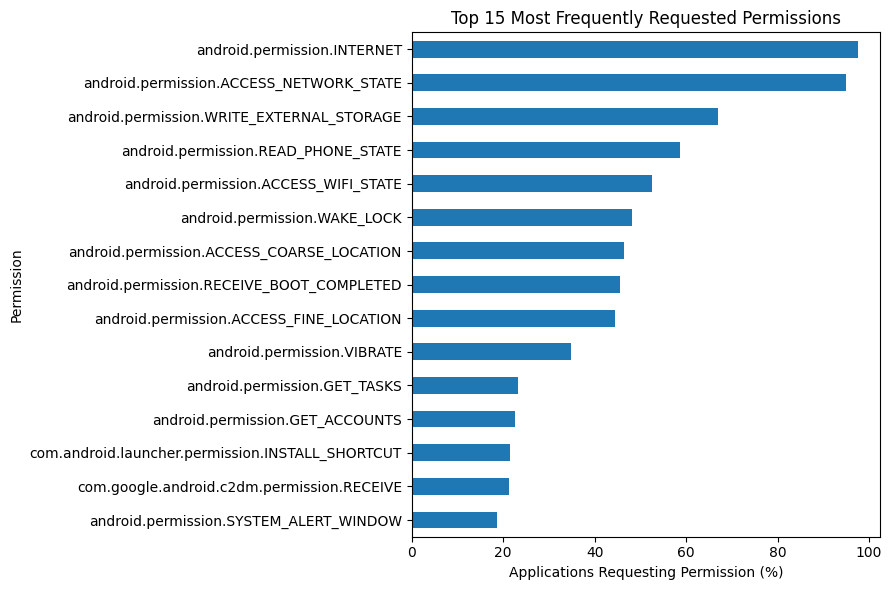

In [ ]:
# Plot the most frequently requested permissions
permission_frequency.sort_values().plot(
    kind='barh',
    figsize=(9, 6)
)

plt.title('Top 15 Most Frequently Requested Permissions')
plt.xlabel('Applications Requesting Permission (%)')
plt.ylabel('Permission')
plt.tight_layout()
plt.show()

### 4.3 Permission Patterns by Application Class

In [ ]:
# Calculate permission rates for each class
permission_by_class = df.groupby('Result').mean().T

permission_by_class.columns = ['Benign', 'Malware']

# Calculate the absolute difference between classes
permission_by_class['Difference'] = (
    permission_by_class['Malware'] -
    permission_by_class['Benign']
).abs()

important_permissions = (
    permission_by_class
    .sort_values('Difference', ascending=False)
    .head(15)
)

important_permissions

,Benign,Malware,Difference
android.permission.READ_PHONE_STATE,0.229975,0.943129,0.713154
android.permission.RECEIVE_BOOT_COMPLETED,0.205919,0.702653,0.496735
android.permission.ACCESS_COARSE_LOCATION,0.248360,0.678435,0.430076
android.permission.ACCESS_FINE_LOCATION,0.242072,0.648027,0.405955
com.google.android.c2dm.permission.RECEIVE,0.411700,0.014082,0.397619
com.android.launcher.permission.INSTALL_SHORTCUT,0.028636,0.398844,0.370208
android.permission.GET_TASKS,0.068617,0.397687,0.329070
android.permission.SYSTEM_ALERT_WINDOW,0.058570,0.314762,0.256192
android.permission.ACCESS_WIFI_STATE,0.419970,0.629660,0.209690
com.android.vending.BILLING,0.219245,0.046395,0.172851


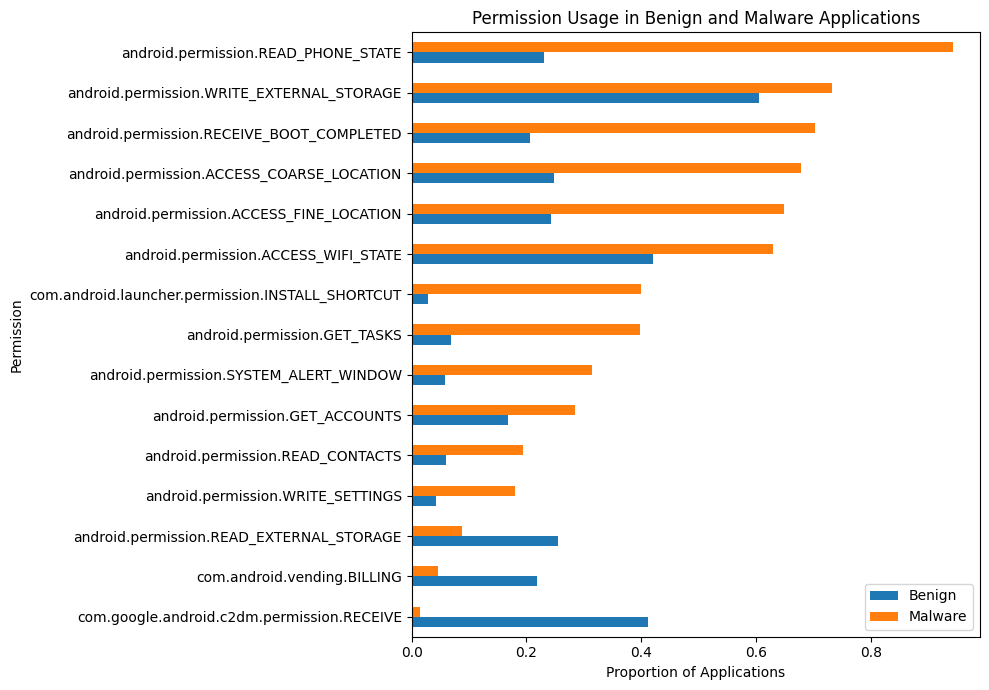

In [ ]:
# Plot permission rates for the two classes
important_permissions[
    ['Benign', 'Malware']
].sort_values('Malware').plot(
    kind='barh',
    figsize=(10, 7)
)

plt.title('Permission Usage in Benign and Malware Applications')
plt.xlabel('Proportion of Applications')
plt.ylabel('Permission')
plt.tight_layout()
plt.show()

Several permissions show noticeably different occurrence rates between benign and malware applications. These differences suggest that permission patterns contain useful predictive information for malware classification.

### 4.4 Number of Permissions Requested per Application

In [ ]:
# Count permissions requested by each application
permission_count = X.sum(axis=1)

permission_count_summary = pd.DataFrame({
    'Permission_Count': permission_count,
    'Result': y
})

permission_count_summary.groupby('Result')['Permission_Count'].agg(
    ['mean', 'median', 'std', 'min', 'max']
)

,mean,median,std,min,max
Result,,,,,
0,8.064038,6.0,6.755891,0,65
1,10.829048,10.0,4.280026,0,52


Malware applications request more permissions on average than benign applications. However, the class distributions overlap, so the number of permissions alone is unlikely to provide sufficient information for reliable classification.

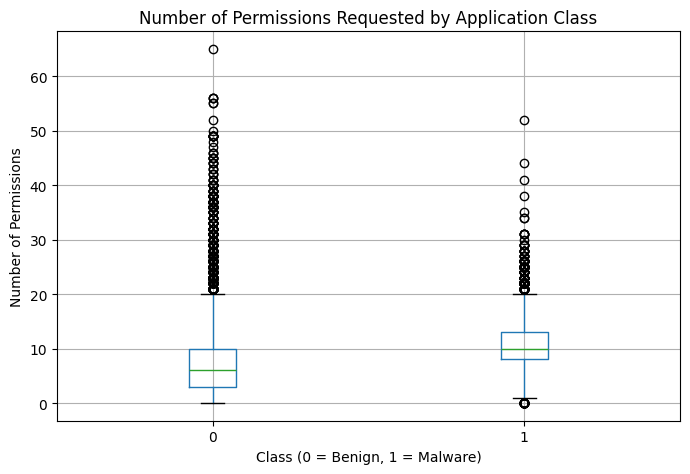

In [ ]:
# Compare permission counts between the classes
permission_count_summary.boxplot(
    column='Permission_Count',
    by='Result',
    figsize=(7, 5)
)

plt.title('Number of Permissions Requested by Application Class')
plt.suptitle('')
plt.xlabel('Class (0 = Benign, 1 = Malware)')
plt.ylabel('Number of Permissions')
plt.tight_layout()
plt.show()

## 5. Training and Test Data

A stratified 70/30 hold-out split is used so that the benign and malware class proportions remain consistent in both datasets. A fixed random state supports reproducibility.

In [ ]:
# Create stratified training and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 20532
Testing records: 8800


In [ ]:
# Check class proportions after splitting
print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

Training class distribution:
Result
0    0.4988
1    0.5012
Name: proportion, dtype: float64

Testing class distribution:
Result
0    0.4989
1    0.5011
Name: proportion, dtype: float64


## 6. Predictive Analytics – Baseline Classification Models

Four supervised classification algorithms are implemented as baseline models: Logistic Regression, k-Nearest Neighbours, Decision Tree, and Bernoulli Naive Bayes. These methods represent different modelling approaches and are suitable for comparison on the binary malware classification problem.

In [ ]:
# Import classification models and evaluation tools
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

### 6.1 Creating the baseline models

In [ ]:
# Define the four baseline classifiers
baseline_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'K-Nearest Neighbours': KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Bernoulli Naive Bayes': BernoulliNB()
}

## 7. Baseline Hold-out Evaluation

The baseline models are trained using the 70% training dataset and evaluated on the 30% hold-out test dataset. Accuracy, precision, recall and F1-score are calculated to compare classification performance.

In [ ]:
# Store baseline performance results
baseline_results = []

# Store predictions for later analysis
baseline_predictions = {}

for name, model in baseline_models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predict the hold-out test data
    y_pred = model.predict(X_test)

    # Store predictions
    baseline_predictions[name] = y_pred

    # Calculate evaluation metrics
    baseline_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

# Create baseline comparison table
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9589,0.9536,0.9649,0.9592
1,K-Nearest Neighbours,0.9620,0.9567,0.9680,0.9624
2,Decision Tree,0.9639,0.9669,0.9608,0.9638
3,Bernoulli Naive Bayes,0.9177,0.9270,0.9073,0.9170


In [ ]:
# Display performance as percentages
baseline_percent_df = baseline_results_df.copy()

for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    baseline_percent_df[metric] = (
        baseline_percent_df[metric] * 100
    ).round(2)

baseline_percent_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,95.89,95.36,96.49,95.92
1,K-Nearest Neighbours,96.20,95.67,96.80,96.24
2,Decision Tree,96.39,96.69,96.08,96.38
3,Bernoulli Naive Bayes,91.77,92.70,90.73,91.70


### 7.1 Baseline Performance Figure

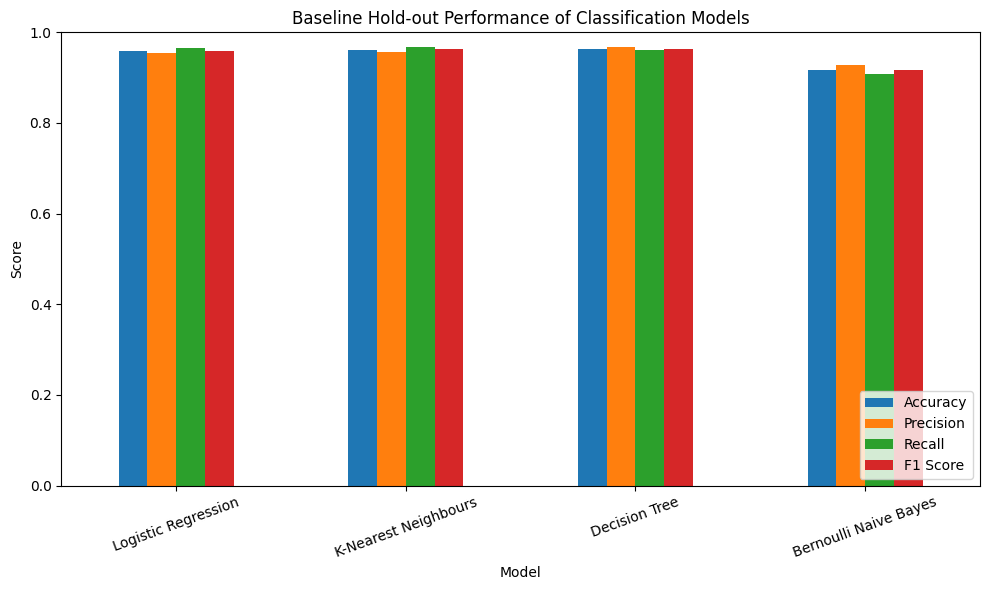

In [ ]:
# Plot baseline model performance
baseline_plot = baseline_results_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
]

baseline_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Baseline Hold-out Performance of Classification Models')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 7.2 Baseline Confusion Matrices

In [ ]:
# Display confusion matrices for baseline models
for name, y_pred in baseline_predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)


Logistic Regression
[[4183  207]
 [ 155 4255]]

K-Nearest Neighbours
[[4197  193]
 [ 141 4269]]

Decision Tree
[[4245  145]
 [ 173 4237]]

Bernoulli Naive Bayes
[[4075  315]
 [ 409 4001]]


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

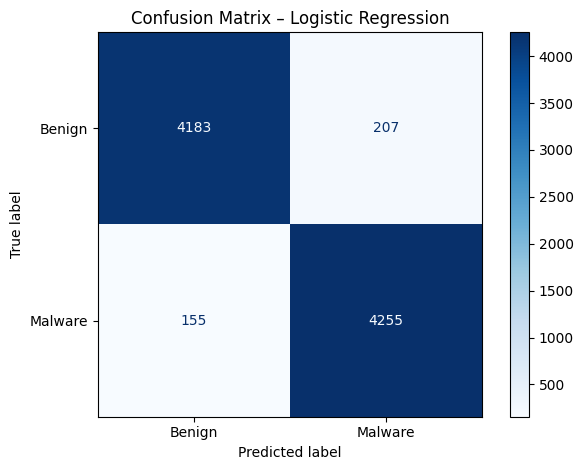

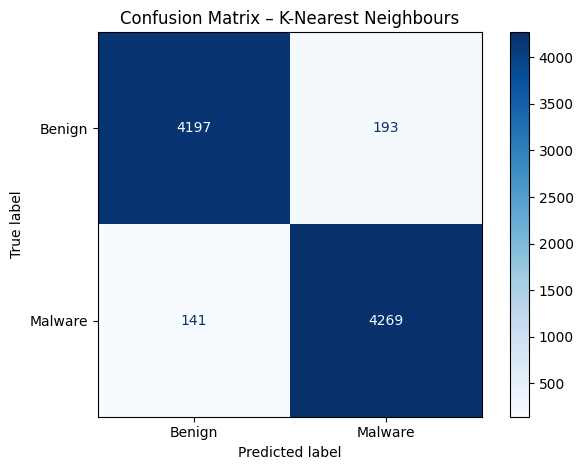

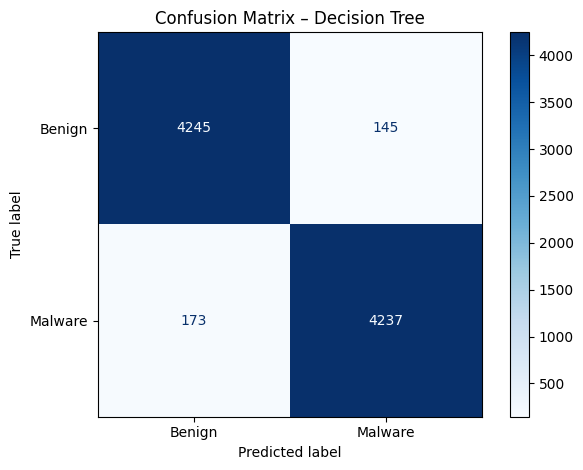

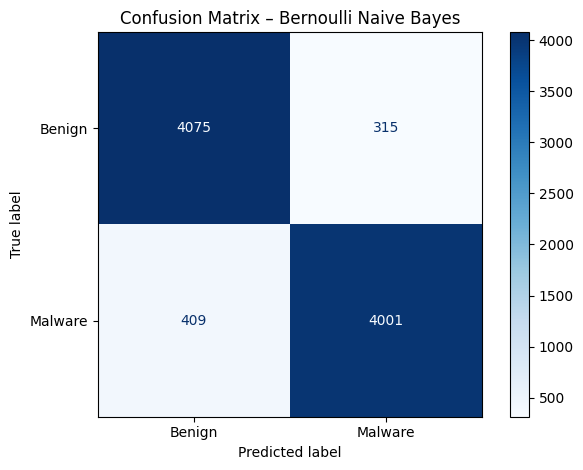

In [ ]:
# Plot confusion matrices
for name, y_pred in baseline_predictions.items():

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=['Benign', 'Malware'],
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix – {name}')
    plt.tight_layout()
    plt.show()

## 8. Hyperparameter Tuning with Grid Search

Grid Search with 5-fold stratified cross-validation is used to test selected hyperparameter combinations for each classifier. F1-score is used as the Grid Search optimisation measure because malware detection requires consideration of both precision and recall.

### 8.1 Cross-validation configuration

In [ ]:
# Define 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### 8.2 Logistic Regression Tuning

In [ ]:
# Define Logistic Regression parameter grid
logistic_param_grid = {
    'C': [0.1, 1, 10]
}

# Create Grid Search
logistic_grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    logistic_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

# Run Grid Search
logistic_grid.fit(X_train, y_train)

print("Best parameters:", logistic_grid.best_params_)
print("Best CV F1-score:", round(logistic_grid.best_score_, 4))

Best parameters: {'C': 10}
Best CV F1-score: 0.9602


### 8.3 k-Nearest Neighbours Tuning

In [ ]:
# Define KNN parameter grid
knn_param_grid = {
    'n_neighbors': [3, 5, 7]
}

# Create Grid Search
knn_grid = GridSearchCV(
    KNeighborsClassifier(
        n_jobs=-1
    ),
    knn_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=1
)

# Run Grid Search
knn_grid.fit(X_train, y_train)

print("Best parameters:", knn_grid.best_params_)
print("Best CV F1-score:", round(knn_grid.best_score_, 4))

Best parameters: {'n_neighbors': 3}
Best CV F1-score: 0.9619


### 8.4 Decision Tree Tuning

In [ ]:
# Define Decision Tree parameter grid
tree_param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

# Create Grid Search
tree_grid = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42
    ),
    tree_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

# Run Grid Search
tree_grid.fit(X_train, y_train)

print("Best parameters:", tree_grid.best_params_)
print("Best CV F1-score:", round(tree_grid.best_score_, 4))

Best parameters: {'max_depth': None, 'min_samples_split': 5}
Best CV F1-score: 0.9625


### 8.5 Bernoulli Naive Bayes Tuning

In [ ]:
# Define Bernoulli Naive Bayes parameter grid
nb_param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0]
}

# Create Grid Search
nb_grid = GridSearchCV(
    BernoulliNB(),
    nb_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

# Run Grid Search
nb_grid.fit(X_train, y_train)

print("Best parameters:", nb_grid.best_params_)
print("Best CV F1-score:", round(nb_grid.best_score_, 4))

Best parameters: {'alpha': 0.1}
Best CV F1-score: 0.9185


### 8.6 Summary of Best Parameters

In [ ]:
# Summarise best Grid Search settings
best_parameters = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'K-Nearest Neighbours',
        'Decision Tree',
        'Bernoulli Naive Bayes'
    ],

    'Best Parameters': [
        logistic_grid.best_params_,
        knn_grid.best_params_,
        tree_grid.best_params_,
        nb_grid.best_params_
    ],

    'Best Grid Search F1': [
        logistic_grid.best_score_,
        knn_grid.best_score_,
        tree_grid.best_score_,
        nb_grid.best_score_
    ]
})

best_parameters['Best Grid Search F1'] = (
    best_parameters['Best Grid Search F1']
    .round(4)
)

best_parameters

,Model,Best Parameters,Best Grid Search F1
0,Logistic Regression,{'C': 10},0.9602
1,K-Nearest Neighbours,{'n_neighbors': 3},0.9619
2,Decision Tree,"{'max_depth': None, 'min_samples_split': 5}",0.9625
3,Bernoulli Naive Bayes,{'alpha': 0.1},0.9185


## 9. Tuned Model Cross-Validation Evaluation

The best model configuration obtained from Grid Search is evaluated using the same 5-fold stratified cross-validation process. Accuracy, precision, recall and F1-score are averaged across the five folds to provide more stable evidence of model performance.

In [ ]:
# Collect the best tuned models
tuned_models = {
    'Logistic Regression': logistic_grid.best_estimator_,
    'K-Nearest Neighbours': knn_grid.best_estimator_,
    'Decision Tree': tree_grid.best_estimator_,
    'Bernoulli Naive Bayes': nb_grid.best_estimator_
}

In [ ]:
# Define cross-validation metrics
scoring = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1 Score': 'f1'
}

In [ ]:
# Store cross-validation results
cv_results = []

for name, model in tuned_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_Accuracy'].mean(),
        'Precision': scores['test_Precision'].mean(),
        'Recall': scores['test_Recall'].mean(),
        'F1 Score': scores['test_F1 Score'].mean(),
        'F1 Std': scores['test_F1 Score'].std()
    })

# Create cross-validation comparison table
cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,F1 Std
0,Logistic Regression,0.9599,0.9551,0.9654,0.9602,0.0019
1,K-Nearest Neighbours,0.9616,0.9572,0.9666,0.9619,0.0022
2,Decision Tree,0.9626,0.9695,0.9556,0.9625,0.0038
3,Bernoulli Naive Bayes,0.9199,0.9366,0.9012,0.9185,0.0029


### 9.1 Cross-validation Comparison Figure

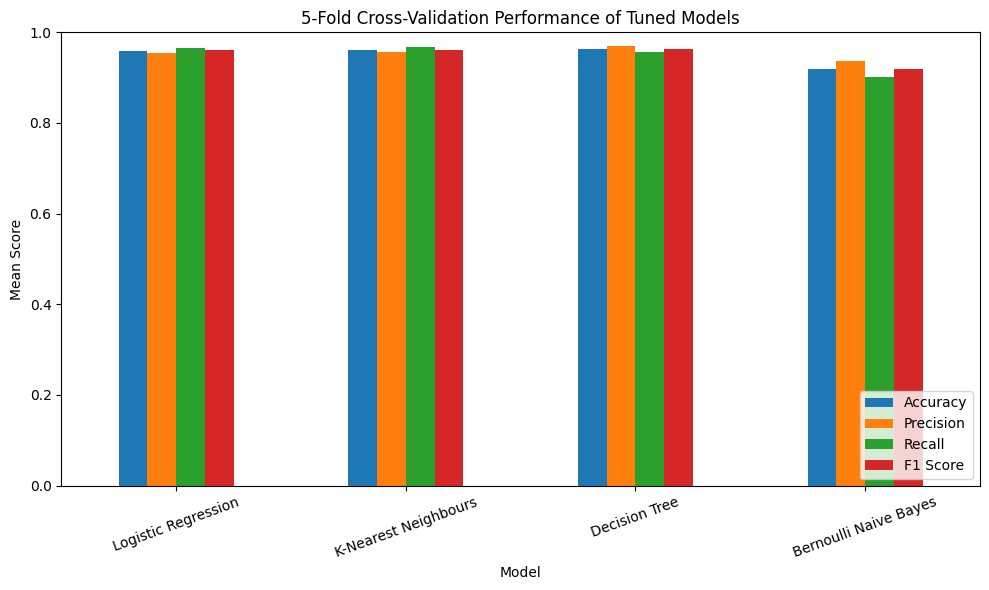

In [ ]:
# Plot tuned cross-validation performance
cv_plot = cv_results_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
]

cv_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('5-Fold Cross-Validation Performance of Tuned Models')
plt.xlabel('Model')
plt.ylabel('Mean Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 10. Tuned Hold-out Evaluation

The tuned models are evaluated on the hold-out test dataset to assess their performance on observations that were not used during Grid Search or cross-validation.

In [ ]:
# Store tuned hold-out results
tuned_test_results = []

tuned_predictions = {}

for name, model in tuned_models.items():

    # Fit tuned model using the training data
    model.fit(X_train, y_train)

    # Predict test data
    y_pred = model.predict(X_test)

    tuned_predictions[name] = y_pred

    tuned_test_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

# Create tuned hold-out comparison table
tuned_test_results_df = pd.DataFrame(
    tuned_test_results
)

tuned_test_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9593,0.9553,0.9639,0.9596
1,K-Nearest Neighbours,0.9640,0.9588,0.9698,0.9643
2,Decision Tree,0.9648,0.9715,0.9578,0.9646
3,Bernoulli Naive Bayes,0.9184,0.9285,0.9070,0.9176


### 10.1 Tuned Confusion Matrices

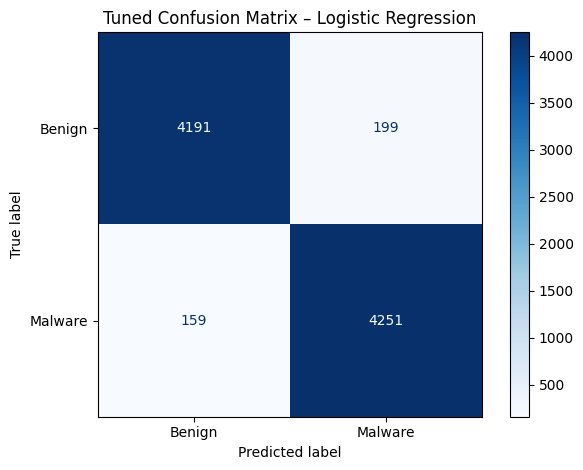

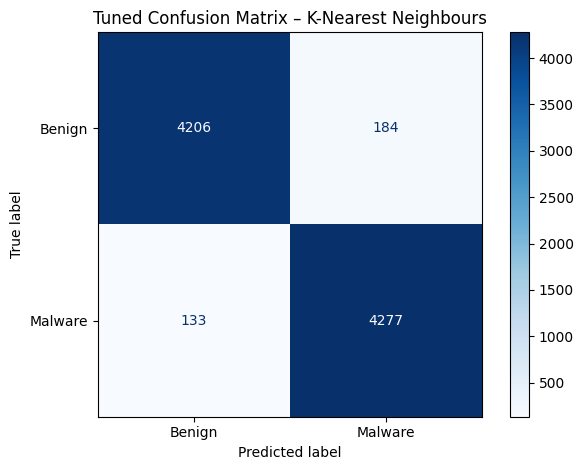

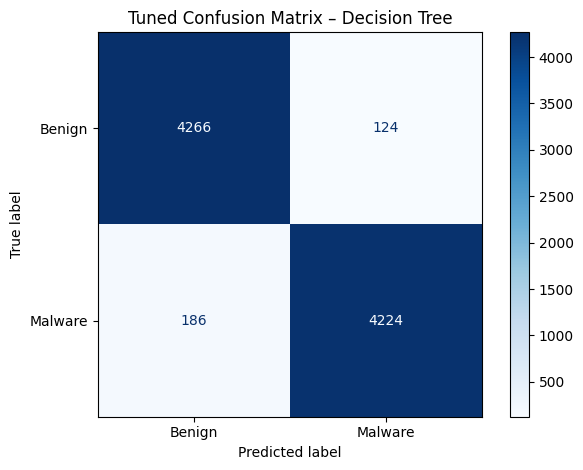

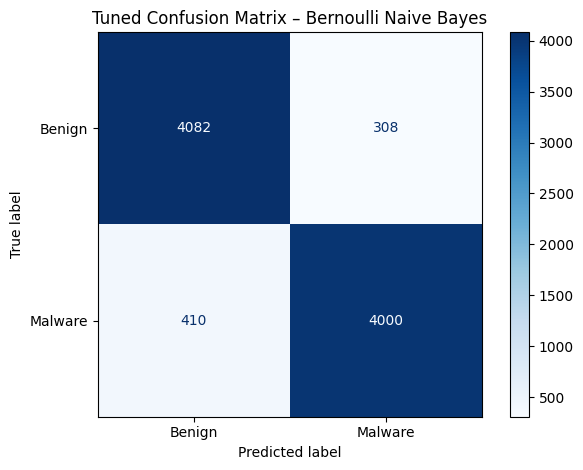

In [ ]:
# Plot confusion matrices for tuned models
for name, y_pred in tuned_predictions.items():

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=['Benign', 'Malware'],
        cmap='Blues'
    )

    plt.title(f'Tuned Confusion Matrix – {name}')
    plt.tight_layout()
    plt.show()

### 10.2 Baseline and Tuned Model Comparison

The hold-out performance of the baseline and tuned models is compared to examine whether Grid Search improved classification performance.

In [ ]:
# Compare baseline and tuned F1-scores
tuning_comparison = baseline_results_df[
    ['Model', 'F1 Score']
].merge(
    tuned_test_results_df[
        ['Model', 'F1 Score']
    ],
    on='Model',
    suffixes=('_Baseline', '_Tuned')
)

tuning_comparison['F1 Change'] = (
    tuning_comparison['F1 Score_Tuned'] -
    tuning_comparison['F1 Score_Baseline']
)

tuning_comparison.round(4)

,Model,F1 Score_Baseline,F1 Score_Tuned,F1 Change
0,Logistic Regression,0.9592,0.9596,0.0004
1,K-Nearest Neighbours,0.9624,0.9643,0.0019
2,Decision Tree,0.9638,0.9646,0.0008
3,Bernoulli Naive Bayes,0.9170,0.9176,0.0006


## 11. Hold-out and Cross-Validation Comparison

In [ ]:
# Compare tuned hold-out and cross-validation results
comparison_df = cv_results_df[
    ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
].merge(
    tuned_test_results_df,
    on='Model',
    suffixes=('_CV', '_Holdout')
)

comparison_df.round(4)

,Model,Accuracy_CV,Precision_CV,Recall_CV,F1 Score_CV,Accuracy_Holdout,Precision_Holdout,Recall_Holdout,F1 Score_Holdout
0,Logistic Regression,0.9599,0.9551,0.9654,0.9602,0.9593,0.9553,0.9639,0.9596
1,K-Nearest Neighbours,0.9616,0.9572,0.9666,0.9619,0.9640,0.9588,0.9698,0.9643
2,Decision Tree,0.9626,0.9695,0.9556,0.9625,0.9648,0.9715,0.9578,0.9646
3,Bernoulli Naive Bayes,0.9199,0.9366,0.9012,0.9185,0.9184,0.9285,0.9070,0.9176


## 12. Select the Best Model Using CV Evidence

In [ ]:
# Select the model with the highest mean cross-validation F1-score
best_model_row = cv_results_df.loc[
    cv_results_df['F1 Score'].idxmax()
]

best_model_name = best_model_row['Model']

print("Best model based on CV F1-score:")
print(best_model_name)

print(
    "Mean CV F1-score:",
    round(best_model_row['F1 Score'], 4)
)

Best model based on CV F1-score:
Decision Tree
Mean CV F1-score: 0.9625


In [ ]:
# Store the selected model for the refinement stage
best_model = tuned_models[best_model_name]

best_model

DecisionTreeClassifier(min_samples_split=5, random_state=42)

Feature-engineering Starting Point: Prashan




